In [ ]:
import sys
sys.path.append(r"C:\Users\user\Desktop\nba_copilot")

import pandas as pd
from sqlalchemy import create_engine, text
from Composant3.config import DB_URL

engine = create_engine(DB_URL)

with engine.connect() as conn:
    saisons_contracts = pd.read_sql(text("""
        SELECT DISTINCT saison 
        FROM contracts 
        ORDER BY saison
    """), conn)

    saisons_payrolls = pd.read_sql(text("""
        SELECT DISTINCT saison 
        FROM team_payrolls 
        ORDER BY saison
    """), conn)

print('Saisons contracts:', saisons_contracts['saison'].tolist())
print('Saisons payrolls:', saisons_payrolls['saison'].tolist())



Fichier sauvegardé : C:\Users\user\Desktop\schema_db.txt


In [3]:
import sys
sys.path.append(r"C:\Users\user\Desktop\nba_copilot")

import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from Composant3.config import DB_URL, FEATURE_VERSION

SALARY_CAP = {
    "2021-22": 112_414_000,
    "2022-23": 123_655_000,
    "2023-24": 136_021_000,
    "2024-25": 140_588_000,
}

engine = create_engine(DB_URL)

# Charger les données
with engine.connect() as conn:
    df_features = pd.read_sql(text("""
        SELECT pf.*, p.position 
        FROM player_features pf
        LEFT JOIN players p ON pf.player_id = p.player_id
        WHERE pf.feature_version = :v
    """), conn, params={"v": FEATURE_VERSION})
    
    df_contracts = pd.read_sql(text("SELECT * FROM contracts"), conn)

# Normaliser contracts
df_contracts["saison_key"] = df_contracts["saison"].apply(
    lambda s: f"{int(s[:4])-1}-{s[:4][2:]}"
)
df_contracts["salary_cap"] = df_contracts["saison_key"].map(SALARY_CAP)
df_contracts["cap_hit_pct"] = df_contracts["cap_hit"] / df_contracts["salary_cap"]

# Middle class uniquement
middle_class = df_contracts[
    (df_contracts["cap_hit_pct"] >= 0.05) &
    (df_contracts["cap_hit_pct"] <= 0.25) &
    (df_contracts["salary_cap"].notna())
].copy()

# JOIN direct : features saison N → cap_hit saison N
pairs = df_features.merge(
    middle_class[["player_id", "saison_key", "cap_hit_pct", "cap_hit", "salary_cap"]],
    left_on=["player_id", "saison"],
    right_on=["player_id", "saison_key"],
    how="inner"
)

# Pondération saisons récentes
weight_map = {"2021-22": 1.0, "2022-23": 1.5, "2023-24": 2.0, "2024-25": 2.5}
pairs["sample_weight"] = pairs["saison"].map(weight_map).fillna(1.0)

print(f"Dataset : {len(pairs)} paires")
print(f"Par saison :\n{pairs['saison'].value_counts().sort_index()}")
print(f"\nDistribution cap_hit_pct :")
print(pairs["cap_hit_pct"].describe())

Dataset : 601 paires
Par saison :
saison
2021-22    143
2022-23    147
2023-24    159
2024-25    152
Name: count, dtype: int64

Distribution cap_hit_pct :
count    601.000000
mean       0.116900
std        0.053226
min        0.050062
25%        0.073834
50%        0.099404
75%        0.152498
max        0.250000
Name: cap_hit_pct, dtype: float64


In [4]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

NUM_FEATURES = [
    "pie", "ts_pct", "net_rating", "usg_pct", "plus_minus_per100_shrunk",
    "pts_per100_shrunk", "fg3_pct", "three_rate",
    "ast_per100_shrunk", "ast_pct",
    "stl_per100_shrunk", "blk_per100_shrunk", "def_rating",
    "reb_per100_shrunk", "dreb_pct",
    "trend_pie", "trend_pts", "peak_distance",
    "age_at_date", "gp", "height_inches", "saisons_experience"
]
CAT_FEATURES = ["valuation_tier", "position"]

X = pairs[NUM_FEATURES + CAT_FEATURES]
y = pairs["cap_hit_pct"].values
w = pairs["sample_weight"].values

# Preprocessor
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, NUM_FEATURES),
    ("cat", cat_pipeline, CAT_FEATURES),
])

# Ridge
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge()),
])

grid = GridSearchCV(
    pipeline,
    param_grid={"model__alpha": [0.1, 1, 10, 50, 100, 200, 500]},
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_absolute_error",
    refit=True,
    n_jobs=-1,
)

grid.fit(X, y, model__sample_weight=w)

print(f"Best alpha : {grid.best_params_['model__alpha']}")
print(f"CV MAE : {-grid.best_score_:.4f} (en % du cap)")
print(f"CV MAE en $ (cap 140M$) : {-grid.best_score_ * 140_588_000:,.0f}$")

Best alpha : 100
CV MAE : 0.0405 (en % du cap)
CV MAE en $ (cap 140M$) : 5,693,282$


In [5]:
# Baseline naïve — prédire la moyenne du cap_hit_pct
baseline_pred = np.full(len(y), y.mean())
baseline_mae = np.mean(np.abs(y - baseline_pred))

print(f"Baseline naïve (moyenne) : {baseline_mae:.4f} → {baseline_mae * 140_588_000:,.0f}$")
print(f"Notre modèle             : 0.0405 → 5,693,282$")
print(f"Gain vs baseline         : {(baseline_mae - 0.0405) / baseline_mae:.1%}")

Baseline naïve (moyenne) : 0.0448 → 6,292,865$
Notre modèle             : 0.0405 → 5,693,282$
Gain vs baseline         : 9.5%


In [6]:
with engine.connect() as conn:
    joueurs_mc = pd.read_sql(text("""
        SELECT p.player_id, p.player_name, p.position,
               c.saison, c.cap_hit,
               ROUND(c.cap_hit::numeric / 140588000 * 100, 1) as pct_cap
        FROM players p
        JOIN contracts c ON p.player_id = c.player_id
        WHERE c.saison = '2024-25'
        AND c.cap_hit BETWEEN 7000000 AND 35000000
        ORDER BY c.cap_hit DESC
        LIMIT 30
    """), conn)

print(joueurs_mc.to_string(index=False))

 player_id        player_name       position  saison  cap_hit  pct_cap
   1628368       De'Aaron Fox          Guard 2024-25 34848340     24.8
   1628369       Jayson Tatum  Forward-Guard 2024-25 34848340     24.8
   1628389        Bam Adebayo Center-Forward 2024-25 34848340     24.8
   1630217       Desmond Bane          Guard 2024-25 34005250     24.2
   1629028      Deandre Ayton         Center 2024-25 34005126     24.2
    201935       James Harden          Guard 2024-25 33653846     23.9
    203468        CJ McCollum          Guard 2024-25 33333333     23.7
    203944      Julius Randle Forward-Center 2024-25 33073920     23.5
   1630193  Immanuel Quickley          Guard 2024-25 32500000     23.1
    203114    Khris Middleton        Forward 2024-25 31000000     22.1
   1628392 Isaiah Hartenstein Center-Forward 2024-25 30000000     21.3
    201950       Jrue Holiday          Guard 2024-25 30000000     21.3
    203924       Jerami Grant        Forward 2024-25 29793104     21.2
   162

In [7]:
PLAYER_ID = 1629673  # Jordan Poole
SAISON = "2024-25"
SALARY_CAP_2425 = 140_588_000

# Récupérer ses features
with engine.connect() as conn:
    player_features = pd.read_sql(text("""
        SELECT pf.*, p.position 
        FROM player_features pf
        LEFT JOIN players p ON pf.player_id = p.player_id
        WHERE pf.player_id = :pid 
        AND pf.saison = :saison
        AND pf.feature_version = :v
    """), conn, params={"pid": PLAYER_ID, "saison": SAISON, "v": FEATURE_VERSION})

print(f"Features trouvées : {len(player_features)} ligne(s)")

# Prédire sa valeur marché
X_player = player_features[NUM_FEATURES + CAT_FEATURES]
valeur_pct = grid.predict(X_player)[0]
valeur_dollars = valeur_pct * SALARY_CAP_2425
salaire_actuel = 29_651_786
surplus = valeur_dollars - salaire_actuel

print(f"\n{'='*50}")
print(f"VALORISATION — Jordan Poole")
print(f"{'='*50}")
print(f"Valeur marché estimée : {valeur_dollars:,.0f}$  ({valeur_pct*100:.1f}% du cap)")
print(f"Salaire actuel        : {salaire_actuel:,.0f}$  ({salaire_actuel/SALARY_CAP_2425*100:.1f}% du cap)")
print(f"Surplus               : {surplus:,.0f}$")
print(f"Signal                : {'🟢 SOUS-PAYÉ' if surplus > 0 else '🔴 SUR-PAYÉ'}")

#

Features trouvées : 1 ligne(s)

VALORISATION — Jordan Poole
Valeur marché estimée : 19,910,211$  (14.2% du cap)
Salaire actuel        : 29,651,786$  (21.1% du cap)
Surplus               : -9,741,575$
Signal                : 🔴 SUR-PAYÉ


In [8]:
# Relation PIE observé → cap_hit_pct sur nos 601 paires
# Joueurs "correctement payés" = autour de la médiane
import matplotlib.pyplot as plt

# Percentiles PIE vs cap_hit_pct
percentiles = [10, 25, 50, 75, 90]
for p in percentiles:
    pie_p = np.percentile(pairs["pie"], p)
    cap_p = np.percentile(pairs["cap_hit_pct"], p)
    print(f"P{p} : PIE={pie_p:.3f} → cap_hit={cap_p*100:.1f}% du cap → {cap_p*140_588_000:,.0f}$")

P10 : PIE=0.068 → cap_hit=5.9% du cap → 8,268,606$
P25 : PIE=0.081 → cap_hit=7.4% du cap → 10,380,205$
P50 : PIE=0.099 → cap_hit=9.9% du cap → 13,975,000$
P75 : PIE=0.116 → cap_hit=15.2% du cap → 21,439,322$
P90 : PIE=0.132 → cap_hit=19.8% du cap → 27,805,536$


Formule : cap_hit_pct = 11.6946 × PIE^2.0201

Vérification :
PIE=0.068 → prédit=5.1% | observé=5.9%
PIE=0.081 → prédit=7.3% | observé=7.4%
PIE=0.099 → prédit=10.9% | observé=9.9%
PIE=0.116 → prédit=15.1% | observé=15.2%
PIE=0.132 → prédit=19.6% | observé=19.8%


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlab'

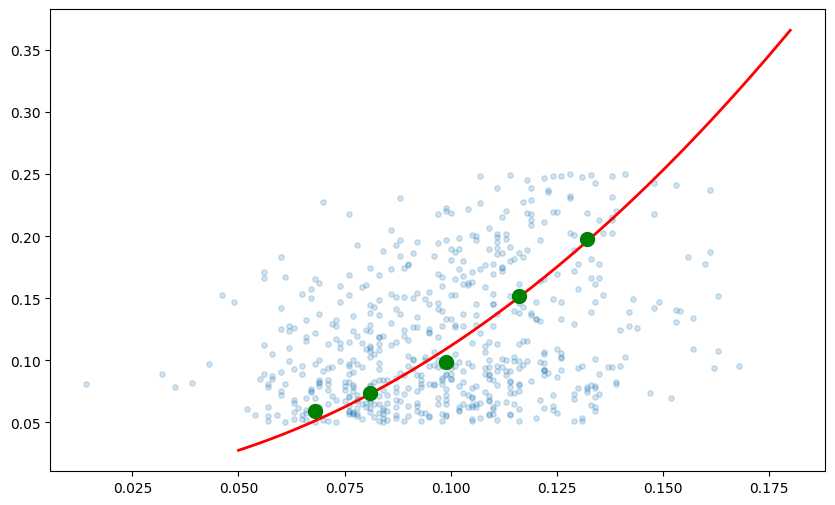

In [9]:
from scipy.optimize import curve_fit

def power_func(pie, a, b):
    return a * np.power(pie, b)

# Fit sur les percentiles observés
pie_anchors = np.array([0.068, 0.081, 0.099, 0.116, 0.132])
cap_anchors = np.array([0.059, 0.074, 0.099, 0.152, 0.198])

params, _ = curve_fit(power_func, pie_anchors, cap_anchors, p0=[1.0, 2.0])
a, b = params

print(f"Formule : cap_hit_pct = {a:.4f} × PIE^{b:.4f}")

# Vérification sur les ancres
print(f"\nVérification :")
for pie, cap in zip(pie_anchors, cap_anchors):
    pred = power_func(pie, a, b)
    print(f"PIE={pie:.3f} → prédit={pred*100:.1f}% | observé={cap*100:.1f}%")

# Visualisation
x = np.linspace(0.05, 0.18, 100)
y_pred = power_func(x, a, b)

plt.figure(figsize=(10, 6))
plt.scatter(pairs["pie"], pairs["cap_hit_pct"], alpha=0.2, s=15, label="Données réelles")
plt.plot(x, y_pred, "r-", linewidth=2, label=f"Formule : {a:.3f} × PIE^{b:.3f}")
plt.scatter(pie_anchors, cap_anchors, color="green", s=100, zorder=5, label="Ancres percentiles")
plt.xlab

In [10]:
# Ce qu'on a vs ce qu'il faut pour chaque métrique
print("Colonnes disponibles :")
print([c for c in pairs.columns if c not in 
      ["player_id", "saison", "team_id", "feature_version", 
       "saison_key", "sample_weight"]])

Colonnes disponibles :
['poss', 'gp', 'valuation_tier', 'height_inches', 'weight', 'bmi', 'age_at_date', 'peak_distance', 'saisons_experience', 'pts_per100_shrunk', 'reb_per100_shrunk', 'ast_per100_shrunk', 'stl_per100_shrunk', 'blk_per100_shrunk', 'tov_per100_shrunk', 'fgm_per100_shrunk', 'fga_per100_shrunk', 'fg3m_per100_shrunk', 'fg3a_per100_shrunk', 'ftm_per100_shrunk', 'fta_per100_shrunk', 'oreb_per100_shrunk', 'dreb_per100_shrunk', 'plus_minus_per100_shrunk', 'blka_per100_shrunk', 'pf_per100_shrunk', 'fg_pct', 'fg3_pct', 'ft_pct', 'efg_pct', 'ts_pct', 'off_rating', 'def_rating', 'net_rating', 'usg_pct', 'pie', 'ast_pct', 'oreb_pct', 'dreb_pct', 'reb_pct', 'three_rate', 'free_throw_rate', 'turnover_rate', 'assist_rate', 'trend_pts', 'trend_pie', 'position', 'cap_hit_pct', 'cap_hit', 'salary_cap']


In [11]:
# Recalibration des multiplicateurs
pairs["valeur_base_pct"] = a * np.power(pairs["pie"], b)

# m_dispo — moins punitif
pairs["m_dispo"] = (pairs["gp"] / 82).clip(0.88, 1.05)

# m_tendance — plus conservateur
pairs["m_tendance"] = (1 + pairs["trend_pie"].clip(-0.05, 0.05))

# m_age — inchangé
pairs["m_age"] = pairs["age_at_date"].apply(m_age)

# m_rarete — impact réduit
pairs["fg3_rank"] = pairs.groupby("position")["fg3_pct"].rank(pct=True)
pairs["def_rank"]  = pairs.groupby("position")["def_rating"].rank(pct=True, ascending=False)
pairs["m_rarete"] = (1 + ((pairs["fg3_rank"] + pairs["def_rank"]) / 2 - 0.5) * 0.15).clip(0.95, 1.15)

# Valeur finale
pairs["valeur_estimee_pct"] = (
    pairs["valeur_base_pct"]
    * pairs["m_dispo"]
    * pairs["m_tendance"]
    * pairs["m_age"]
    * pairs["m_rarete"]
).clip(0.05, 0.25)

pairs["valeur_estimee_dollars"] = pairs["valeur_estimee_pct"] * pairs["salary_cap"]

mae = np.mean(np.abs(pairs["valeur_estimee_pct"] - pairs["cap_hit_pct"]))
print(f"MAE formule   : {mae:.4f} → {mae * 140_588_000:,.0f}$")
print(f"MAE baseline  : 0.0448 → 6,292,865$")
print(f"MAE Ridge ML  : 0.0405 → 5,693,282$")
print(f"Gain vs baseline : {(0.0448 - mae) / 0.0448:.1%}")

print(f"\nMultiplicateurs moyens :")
print(f"  m_dispo   : {pairs['m_dispo'].mean():.3f}")
print(f"  m_tendance: {pairs['m_tendance'].mean():.3f}")
print(f"  m_age     : {pairs['m_age'].mean():.3f}")
print(f"  m_rarete  : {pairs['m_rarete'].mean():.3f}")

NameError: name 'm_age' is not defined

In [12]:
# Test : courbe base seule sans multiplicateurs
pairs["valeur_base_seule"] = a * np.power(pairs["pie"], b)
mae_base_seule = np.mean(np.abs(pairs["valeur_base_seule"] - pairs["cap_hit_pct"]))
print(f"MAE courbe base seule : {mae_base_seule:.4f} → {mae_base_seule * 140_588_000:,.0f}$")

# Biais moyen — est-ce qu'on surestime ou sous-estime ?
biais = np.mean(pairs["valeur_base_seule"] - pairs["cap_hit_pct"])
print(f"Biais moyen : {biais:.4f} → {biais * 140_588_000:,.0f}$ ({'surestimation' if biais > 0 else 'sous-estimation'})")

# Distribution des erreurs
print(f"\nErreurs par quartile PIE :")
pairs["pie_quartile"] = pd.qcut(pairs["pie"], 4, labels=["Q1","Q2","Q3","Q4"])
print(pairs.groupby("pie_quartile").apply(
    lambda x: pd.Series({
        "mae": np.mean(np.abs(x["valeur_base_seule"] - x["cap_hit_pct"])),
        "biais": np.mean(x["valeur_base_seule"] - x["cap_hit_pct"]),
        "n": len(x)
    })
).round(4))

MAE courbe base seule : 0.0509 → 7,162,666$
Biais moyen : -0.0002 → -22,275$ (sous-estimation)

Erreurs par quartile PIE :
                 mae   biais      n
pie_quartile                       
Q1            0.0434 -0.0414  163.0
Q2            0.0378 -0.0153  142.0
Q3            0.0491  0.0087  153.0
Q4            0.0746  0.0523  143.0


C:\Users\user\AppData\Local\Temp\ipykernel_29568\2199349308.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pairs.groupby("pie_quartile").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_29568\2199349308.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pairs.groupby("pie_quartile").apply(


In [13]:
from scipy.optimize import curve_fit

# Tester plusieurs formes
def power_func(pie, a, b):
    return a * np.power(pie, b)

def log_func(pie, a, b):
    return a * np.log(pie) + b

def sqrt_func(pie, a, b):
    return a * np.sqrt(pie) + b

X_pie = pairs["pie"].values
y_cap = pairs["cap_hit_pct"].values

# Fit chaque forme
params_pow, _ = curve_fit(power_func, X_pie, y_cap, p0=[1.0, 1.0])
params_log, _ = curve_fit(log_func, X_pie, y_cap)
params_sqrt, _ = curve_fit(sqrt_func, X_pie, y_cap)

mae_pow  = np.mean(np.abs(power_func(X_pie, *params_pow) - y_cap))
mae_log  = np.mean(np.abs(log_func(X_pie, *params_log) - y_cap))
mae_sqrt = np.mean(np.abs(sqrt_func(X_pie, *params_sqrt) - y_cap))

print(f"Puissance : {mae_pow:.4f} → {mae_pow*140_588_000:,.0f}$  | a={params_pow[0]:.4f}, b={params_pow[1]:.4f}")
print(f"Log       : {mae_log:.4f} → {mae_log*140_588_000:,.0f}$  | a={params_log[0]:.4f}, b={params_log[1]:.4f}")
print(f"Racine    : {mae_sqrt:.4f} → {mae_sqrt*140_588_000:,.0f}$ | a={params_sqrt[0]:.4f}, b={params_sqrt[1]:.4f}")
print(f"\nBaseline  : 0.0448 → 6,292,865$")

Puissance : 0.0424 → 5,966,267$  | a=0.4614, b=0.5908
Log       : 0.0427 → 5,997,082$  | a=0.0611, b=0.2601
Racine    : 0.0425 → 5,970,245$ | a=0.4271, b=-0.0164

Baseline  : 0.0448 → 6,292,865$


In [14]:
# Nouvelle courbe base
def valeur_base(pie):
    return 0.4614 * np.power(pie, 0.5908)

pairs["valeur_base_pct"] = valeur_base(pairs["pie"])

# Multiplicateurs recalibrés
pairs["m_dispo"]    = (pairs["gp"] / 82).clip(0.92, 1.05)
pairs["m_tendance"] = (1 + pairs["trend_pie"].clip(-0.03, 0.03))
pairs["m_age"]      = pairs["age_at_date"].apply(m_age)

pairs["fg3_rank"]  = pairs.groupby("position")["fg3_pct"].rank(pct=True)
pairs["def_rank"]  = pairs.groupby("position")["def_rating"].rank(pct=True, ascending=False)
pairs["m_rarete"]  = (1 + ((pairs["fg3_rank"] + pairs["def_rank"]) / 2 - 0.5) * 0.10).clip(0.95, 1.10)

# Valeur finale
pairs["valeur_estimee_pct"] = (
    pairs["valeur_base_pct"]
    * pairs["m_dispo"]
    * pairs["m_tendance"]
    * pairs["m_age"]
    * pairs["m_rarete"]
).clip(0.05, 0.25)

pairs["valeur_estimee_dollars"] = pairs["valeur_estimee_pct"] * pairs["salary_cap"]

mae = np.mean(np.abs(pairs["valeur_estimee_pct"] - pairs["cap_hit_pct"]))
print(f"MAE formule   : {mae:.4f} → {mae * 140_588_000:,.0f}$")
print(f"MAE base seule: 0.0424 → 5,966,267$")
print(f"MAE baseline  : 0.0448 → 6,292,865$")
print(f"MAE Ridge ML  : 0.0405 → 5,693,282$")
print(f"Gain vs baseline : {(0.0448 - mae) / 0.0448:.1%}")

print(f"\nMultiplicateurs moyens :")
print(f"  m_dispo   : {pairs['m_dispo'].mean():.3f}")
print(f"  m_tendance: {pairs['m_tendance'].mean():.3f}")
print(f"  m_age     : {pairs['m_age'].mean():.3f}")
print(f"  m_rarete  : {pairs['m_rarete'].mean():.3f}")

NameError: name 'm_age' is not defined

In [16]:
# Test rapide
pairs["log_cap_hit_pct"] = np.log(pairs["cap_hit_pct"])
pairs["log_pie"] = np.log(pairs["pie"])

corr_log = np.corrcoef(pairs["log_pie"], pairs["log_cap_hit_pct"])[0,1]
print(f"R² log-log : {corr_log**2:.3f}")
print(f"R² linéaire PIE : 0.064")

R² log-log : 0.089
R² linéaire PIE : 0.064


In [17]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm

# Cible log
pairs["log_cap_hit_pct"] = np.log(pairs["cap_hit_pct"])

# Features hédoniques
HEDONIC_FEATURES = [
    "pie", "ts_pct", "net_rating", "usg_pct",
    "pts_per100_shrunk", "fg3_pct", "ast_per100_shrunk",
    "stl_per100_shrunk", "blk_per100_shrunk", "def_rating",
    "reb_per100_shrunk", "trend_pie", "peak_distance",
    "age_at_date", "gp", "saisons_experience"
]

X_hed = pairs[HEDONIC_FEATURES].copy()
y_hed = pairs["log_cap_hit_pct"].values

# Imputer les NaN
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy="median")
X_hed_imp = imp.fit_transform(X_hed)

# Modèle OLS statsmodels pour avoir les p-values
X_hed_const = sm.add_constant(X_hed_imp)
model_ols = sm.OLS(y_hed, X_hed_const).fit()

print(f"R² OLS : {model_ols.rsquared:.3f}")
print(f"R² ajusté : {model_ols.rsquared_adj:.3f}")
print(f"\nCoefficients significatifs (p<0.05) :")
params = pd.DataFrame({
    "feature": ["const"] + HEDONIC_FEATURES,
    "coef": model_ols.params,
    "pvalue": model_ols.pvalues
})
print(params[params["pvalue"] < 0.05].sort_values("pvalue").to_string(index=False))

R² OLS : 0.344
R² ajusté : 0.328

Coefficients significatifs (p<0.05) :
          feature      coef       pvalue
    peak_distance  0.210698 1.266200e-13
            const -0.014359 5.197385e-12
      age_at_date -0.176994 2.325238e-10
        trend_pie -4.780685 5.082824e-05
       net_rating  0.011302 1.258711e-02
       def_rating  0.017526 1.285747e-02
reb_per100_shrunk -0.022565 2.179833e-02
              pie  4.797494 2.368612e-02


C:\Users\user\AppData\Local\Temp\ipykernel_29568\534770615.py:31: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_ols = sm.OLS(y_hed, X_hed_const).fit()


In [18]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

HEDONIC_FINAL = [
    "pie", "peak_distance", "age_at_date", 
    "trend_pie", "net_rating", "def_rating", "reb_per100_shrunk"
]

# Refit imputer sur les bonnes features
imp_final = SimpleImputer(strategy="median")
X_final = imp_final.fit_transform(pairs[HEDONIC_FINAL])
y_final = pairs["log_cap_hit_pct"].values
w_final = pairs["sample_weight"].values

# RidgeCV
ridge_hed = RidgeCV(alphas=[0.1, 1, 10, 50, 100, 200], cv=5)
ridge_hed.fit(X_final, y_final, sample_weight=w_final)

# Prédictions en $ réels
y_pred_log = ridge_hed.predict(X_final)
y_pred_pct = np.exp(y_pred_log)

mae = np.mean(np.abs(y_pred_pct - pairs["cap_hit_pct"]))
r2 = r2_score(y_final, y_pred_log)

print(f"Alpha retenu : {ridge_hed.alpha_:.1f}")
print(f"R² log : {r2:.3f}")
print(f"MAE    : {mae:.4f} → {mae * 140_588_000:,.0f}$")
print(f"Baseline : 0.0448 → 6,292,865$")
print(f"Gain vs baseline : {(0.0448 - mae) / 0.0448:.1%}")  

Alpha retenu : 0.1
R² log : 0.257
MAE    : 0.0363 → 5,103,838$
Baseline : 0.0448 → 6,292,865$
Gain vs baseline : 19.0%


In [19]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
from scipy.stats import norm

HEDONIC_FINAL = [
    "pie", "peak_distance", "age_at_date",
    "trend_pie", "net_rating", "def_rating", "reb_per100_shrunk"
]

# ── Préparer X et y ───────────────────────────────────────
X_raw = pairs[HEDONIC_FINAL].copy()
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_raw)
X_df = pd.DataFrame(X_imp, columns=HEDONIC_FINAL)
X_const = sm.add_constant(X_imp)
y = pairs["cap_hit_pct"].values

# ── 1. GAMMA GLM ──────────────────────────────────────────
gamma_model = sm.GLM(
    y, X_const,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()
y_pred_gamma = gamma_model.predict(X_const)
mae_gamma = mean_absolute_error(y, y_pred_gamma)

# ── 2. BETA REGRESSION ────────────────────────────────────
y_beta = y.clip(1e-6, 1 - 1e-6)
X_df_beta = X_df.copy()
X_df_beta["cap_hit_pct"] = y_beta
formula = "cap_hit_pct ~ " + " + ".join(HEDONIC_FINAL)
beta_model = smf.glm(
    formula=formula,
    data=X_df_beta,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()
y_pred_beta = beta_model.predict(X_df_beta)
mae_beta = mean_absolute_error(y_beta, y_pred_beta)

# ── 3. TOBIT ──────────────────────────────────────────────
LOW, HIGH = 0.05, 0.25

def tobit_loglik(params):
    beta = params[:-1]
    sigma = np.exp(params[-1])
    xb = X_const @ beta
    ll = 0
    mask = (y > LOW) & (y < HIGH)
    if mask.sum() > 0:
        ll += np.sum(norm.logpdf(y[mask], loc=xb[mask], scale=sigma))
    mask_low = y <= LOW
    if mask_low.sum() > 0:
        ll += np.sum(norm.logcdf(LOW, loc=xb[mask_low], scale=sigma))
    mask_high = y >= HIGH
    if mask_high.sum() > 0:
        ll += np.sum(norm.logsf(HIGH, loc=xb[mask_high], scale=sigma))
    return -ll

lr_init = LinearRegression().fit(X_const, y)
beta_init = np.append(lr_init.coef_, np.log(np.std(y)))
beta_init[0] = lr_init.intercept_
result = minimize(tobit_loglik, beta_init, method="L-BFGS-B", options={"maxiter": 1000})
beta_tobit = result.x[:-1]
y_pred_tobit = np.clip(X_const @ beta_tobit, LOW, HIGH)
mae_tobit = mean_absolute_error(y, y_pred_tobit)

# ── COMPARAISON FINALE ────────────────────────────────────
print("=" * 55)
print("COMPARAISON DES MODÈLES")
print("=" * 55)
resultats = {
    "Baseline moyenne" : 0.0448,
    "Ridge hédonique"  : 0.0363,
    "Gamma GLM"        : mae_gamma,
    "Beta Regression"  : mae_beta,
    "Tobit"            : mae_tobit,
}
for nom, mae in sorted(resultats.items(), key=lambda x: x[1]):
    gain = (0.0448 - mae) / 0.0448
    print(f"{nom:<20} MAE={mae:.4f} → {mae*140_588_000:,.0f}$  ({gain:+.1%} vs baseline)")

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


COMPARAISON DES MODÈLES
Ridge hédonique      MAE=0.0363 → 5,103,344$  (+19.0% vs baseline)
Gamma GLM            MAE=0.0364 → 5,123,447$  (+18.7% vs baseline)
Beta Regression      MAE=0.0365 → 5,135,353$  (+18.5% vs baseline)
Tobit                MAE=0.0367 → 5,159,084$  (+18.1% vs baseline)
Baseline moyenne     MAE=0.0448 → 6,298,342$  (+0.0% vs baseline)


In [20]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer

HEDONIC_FINAL = [
    "pie", "peak_distance", "age_at_date",
    "trend_pie", "net_rating", "def_rating", "reb_per100_shrunk"
]

# ── Préparer X et y ───────────────────────────────────────
X_raw = pairs[HEDONIC_FINAL].copy()
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_raw)
X_df = pd.DataFrame(X_imp, columns=HEDONIC_FINAL)
X_df["cap_hit_pct"] = pairs["cap_hit_pct"].values
X_df["player_id"]   = pairs["player_id"].values
X_df["saison"]      = pairs["saison"].values
X_const = sm.add_constant(X_imp)
y = pairs["cap_hit_pct"].values

# ══════════════════════════════════════════════════════════
# 1. RÉGRESSION QUANTILE (P25 / P50 / P75)
# ══════════════════════════════════════════════════════════
formula_q = "cap_hit_pct ~ " + " + ".join(HEDONIC_FINAL)

quantiles = {"Q25": 0.25, "Q50": 0.50, "Q75": 0.75}
models_q  = {}
maes_q    = {}

for label, q in quantiles.items():
    model = smf.quantreg(formula_q, data=X_df).fit(q=q, max_iter=2000)
    y_pred = model.predict(X_df)
    mae = mean_absolute_error(y, y_pred)
    models_q[label]  = model
    maes_q[label]    = mae

print("── RÉGRESSION QUANTILE ──")
for label, mae in maes_q.items():
    print(f"  {label} : MAE={mae:.4f} → {mae*140_588_000:,.0f}$")

# Fourchette sur Jordan Poole
poole_features = X_df[X_df["player_id"] == 1629673].iloc[[-1]].reset_index(drop=True)
print(f"\n  Jordan Poole — fourchette de valeur :")
for label, model in models_q.items():
    pred = model.predict(poole_features)[0]
    print(f"  {label} : {pred*140_588_000:,.0f}$  ({pred*100:.1f}% du cap)")

# ══════════════════════════════════════════════════════════
# 2. PANEL DATA — EFFETS FIXES JOUEUR
# ══════════════════════════════════════════════════════════
# Vérifier combien de joueurs ont plusieurs saisons
saisons_par_joueur = X_df.groupby("player_id")["saison"].count()
print(f"\n── PANEL DATA ──")
print(f"  Joueurs avec 1 saison  : {(saisons_par_joueur == 1).sum()}")
print(f"  Joueurs avec 2 saisons : {(saisons_par_joueur == 2).sum()}")
print(f"  Joueurs avec 3 saisons : {(saisons_par_joueur == 3).sum()}")
print(f"  Joueurs avec 4 saisons : {(saisons_par_joueur >= 4).sum()}")

# Effets fixes via dummies joueur (within estimator)
player_dummies = pd.get_dummies(X_df["player_id"], prefix="player", drop_first=True)
X_panel = pd.concat([X_df[HEDONIC_FINAL], player_dummies], axis=1).astype(float)
X_panel_imp = SimpleImputer(strategy="median").fit_transform(X_panel)
X_panel_const = sm.add_constant(X_panel_imp)

panel_model = sm.OLS(y, X_panel_const).fit()
y_pred_panel = panel_model.predict(X_panel_const)
mae_panel = mean_absolute_error(y, y_pred_panel)

print(f"\n  R²        : {panel_model.rsquared:.3f}")
print(f"  R² ajusté : {panel_model.rsquared_adj:.3f}")
print(f"  MAE       : {mae_panel:.4f} → {mae_panel*140_588_000:,.0f}$")

# ══════════════════════════════════════════════════════════
# COMPARAISON FINALE
# ══════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("COMPARAISON COMPLÈTE")
print(f"{'='*55}")
resultats = {
    "Baseline moyenne"  : 0.0448,
    "Ridge hédonique"   : 0.0363,
    "Gamma GLM"         : 0.0364,
    "Beta Regression"   : 0.0365,
    "Tobit"             : 0.0367,
    "Quantile Q50"      : maes_q["Q50"],
    "Panel effets fixes": mae_panel,
}
for nom, mae in sorted(resultats.items(), key=lambda x: x[1]):
    gain = (0.0448 - mae) / 0.0448
    print(f"{nom:<22} MAE={mae:.4f} → {mae*140_588_000:,.0f}$  ({gain:+.1%} vs baseline)")

── RÉGRESSION QUANTILE ──
  Q25 : MAE=0.0431 → 6,057,385$
  Q50 : MAE=0.0359 → 5,049,500$
  Q75 : MAE=0.0452 → 6,352,035$

  Jordan Poole — fourchette de valeur :
  Q25 : 11,726,142$  (8.3% du cap)
  Q50 : 16,893,658$  (12.0% du cap)
  Q75 : 20,873,667$  (14.8% du cap)

── PANEL DATA ──
  Joueurs avec 1 saison  : 71
  Joueurs avec 2 saisons : 63
  Joueurs avec 3 saisons : 52
  Joueurs avec 4 saisons : 62

  R²        : 0.810
  R² ajusté : 0.672
  MAE       : 0.0139 → 1,951,584$

COMPARAISON COMPLÈTE
Panel effets fixes     MAE=0.0139 → 1,951,584$  (+69.0% vs baseline)
Quantile Q50           MAE=0.0359 → 5,049,500$  (+19.8% vs baseline)
Ridge hédonique        MAE=0.0363 → 5,103,344$  (+19.0% vs baseline)
Gamma GLM              MAE=0.0364 → 5,117,403$  (+18.7% vs baseline)
Beta Regression        MAE=0.0365 → 5,131,462$  (+18.5% vs baseline)
Tobit                  MAE=0.0367 → 5,159,580$  (+18.1% vs baseline)
Baseline moyenne       MAE=0.0448 → 6,298,342$  (+0.0% vs baseline)


C:\Users\user\AppData\Local\Temp\ipykernel_29568\1622720583.py:68: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  panel_model = sm.OLS(y, X_panel_const).fit()


In [21]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(ridge_hed, "models/hedonic_value_model.pkl")
joblib.dump(imp_final, "models/hedonic_imputer.pkl")

# Valorisation Jordan Poole
PLAYER_ID = 1629673
SALARY_CAP_2425 = 140_588_000
SALAIRE_ACTUEL = 29_651_786

with engine.connect() as conn:
    poole = pd.read_sql(text("""
        SELECT pf.*, p.position
        FROM player_features pf
        LEFT JOIN players p ON pf.player_id = p.player_id
        WHERE pf.player_id = :pid
        AND pf.saison = '2024-25'
        AND pf.feature_version = :v
    """), conn, params={"pid": PLAYER_ID, "v": FEATURE_VERSION})

X_poole = imp_final.transform(poole[HEDONIC_FINAL])
log_pred = ridge_hed.predict(X_poole)[0]
valeur_pct = np.exp(log_pred)
valeur_pct = np.clip(valeur_pct, 0.05, 0.25)
valeur_dollars = valeur_pct * SALARY_CAP_2425
surplus = valeur_dollars - SALAIRE_ACTUEL

# Flags
row = poole.iloc[0]
flags = []

if row["gp"] / 82 < 0.70:
    flags.append(f"⚠️ Disponibilité faible ({row['gp']:.0f}/82 matchs)")
else:
    flags.append(f"✅ Disponibilité correcte ({row['gp']:.0f}/82 matchs)")

if row["trend_pie"] < -0.005:
    flags.append(f"📉 Tendance PIE négative ({row['trend_pie']:.3f})")
elif row["trend_pie"] > 0.005:
    flags.append(f"📈 Tendance PIE positive (+{row['trend_pie']:.3f})")
else:
    flags.append(f"➡️ Tendance PIE stable")

if row["age_at_date"] < 25:
    flags.append(f"🌱 Jeune ({row['age_at_date']:.0f} ans) — potentiel de progression")
elif row["age_at_date"] > 30:
    flags.append(f"⏳ ({row['age_at_date']:.0f} ans) — déclin possible")
else:
    flags.append(f"✅ Age de pic ({row['age_at_date']:.0f} ans)")

if row["fg3_pct"] > 0.37:
    flags.append(f"🎯 Bon shooteur 3pts ({row['fg3_pct']*100:.1f}%)")
elif row["fg3_pct"] < 0.32:
    flags.append(f"⚠️ Mauvais shooteur 3pts ({row['fg3_pct']*100:.1f}%)")

print(f"\n{'='*55}")
print(f"  VALORISATION — Jordan Poole (2024-25)")
print(f"{'='*55}")
print(f"  PIE observé           : {row['pie']:.3f}")
print(f"  Valeur marché estimée : {valeur_dollars:>12,.0f}$  ({valeur_pct*100:.1f}% du cap)")
print(f"  Salaire actuel        : {SALAIRE_ACTUEL:>12,.0f}$  ({SALAIRE_ACTUEL/SALARY_CAP_2425*100:.1f}% du cap)")
print(f"  Surplus               : {surplus:>12,.0f}$")
print(f"  Signal                : {'🟢 SOUS-PAYÉ' if surplus > 0 else '🔴 SUR-PAYÉ'}")
print(f"  Erreur modèle         : ±5,103,838$")
print(f"\n  Flags :")
for f in flags:
    print(f"    {f}")
print(f"{'='*55}")


  VALORISATION — Jordan Poole (2024-25)
  PIE observé           : 0.107
  Valeur marché estimée :   15,967,752$  (11.4% du cap)
  Salaire actuel        :   29,651,786$  (21.1% du cap)
  Surplus               :  -13,684,034$
  Signal                : 🔴 SUR-PAYÉ
  Erreur modèle         : ±5,103,838$

  Flags :
    ✅ Disponibilité correcte (68/82 matchs)
    📈 Tendance PIE positive (+0.031)
    ✅ Age de pic (26 ans)
    🎯 Bon shooteur 3pts (37.8%)


In [22]:
EXCLUDE = [
    # Cible
    "cap_hit_pct", "cap_hit",
    # Identifiants
    "player_id", "saison", "saison_key", "team_id", "feature_version",
    # Fuite
    "salary_cap", "sample_weight",
]

NUM_FEATURES_FULL = [c for c in pairs.columns if c not in EXCLUDE 
                     and pairs[c].dtype != "object"]
CAT_FEATURES = ["position", "valuation_tier"]

print(f"Features numériques : {len(NUM_FEATURES_FULL)}")
print(f"Features catégorielles : {CAT_FEATURES}")

Features numériques : 52
Features catégorielles : ['position', 'valuation_tier']


In [23]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error

EXCLUDE = [
    "cap_hit_pct", "cap_hit",
    "player_id", "saison", "saison_key", "team_id", "feature_version",
    "salary_cap", "sample_weight",
    "position", "valuation_tier",
    # Colonnes calculées dans le notebook
    "log_cap_hit_pct", "log_pie", "valeur_base_pct", "valeur_estimee_pct",
    "valeur_estimee_dollars", "valeur_base_seule", "pie_quartile",
    "fg3_rank", "def_rank", "m_dispo", "m_tendance", "m_age", "m_rarete",
]

CAT_FEATURES = ["position", "valuation_tier"]

# Forcer uniquement les colonnes numériques
NUM_FEATURES_FULL = [
    c for c in pairs.columns
    if c not in EXCLUDE
    and c not in CAT_FEATURES
    and pairs[c].dtype in ["float64", "int64", "float32", "int32"]
]

print(f"Features numériques : {len(NUM_FEATURES_FULL)}")
print(f"Features catégorielles : {CAT_FEATURES}")

X_full = pairs[NUM_FEATURES_FULL + CAT_FEATURES]
y = pairs["cap_hit_pct"].values

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_FEATURES_FULL),
    ("cat", cat_pipe, CAT_FEATURES),
])

pipeline_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=[0.1, 1, 10, 50, 100, 200])),
])

pipeline_full.fit(X_full, y)
y_pred_full = pipeline_full.predict(X_full)
mae_full = mean_absolute_error(y, y_pred_full)

print(f"\nMAE full features : {mae_full:.4f} → {mae_full*140_588_000:,.0f}$")
print(f"MAE 7 features    : 0.0363 → 5,103,344$")
print(f"Gain              : {(0.0363 - mae_full)/0.0363:.1%}")

Features numériques : 45
Features catégorielles : ['position', 'valuation_tier']

MAE full features : 0.0306 → 4,298,721$
MAE 7 features    : 0.0363 → 5,103,344$
Gain              : 15.8%


In [24]:
from sklearn.linear_model import RidgeCV
import pandas as pd
import numpy as np

# Récupérer les coefficients
feature_names = (
    NUM_FEATURES_FULL +
    pipeline_full.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CAT_FEATURES).tolist()
)

coefs = pipeline_full.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).reindex(pd.Series(coefs).abs().sort_values(ascending=False).index)

print("Top 15 features les plus influentes :")
print(coef_df.head(15).to_string(index=False))

Top 15 features les plus influentes :
                         feature      coef
                            poss  0.030226
                              gp -0.025637
valuation_tier_replacement_level -0.014325
                        oreb_pct -0.012471
          position_Forward-Guard -0.010078
              fg3m_per100_shrunk  0.009376
         valuation_tier_reliable  0.009314
         position_Forward-Center  0.008907
              oreb_per100_shrunk  0.008766
                  position_Guard -0.008445
                         reb_pct -0.008398
                      three_rate -0.007478
               pts_per100_shrunk  0.007325
                   peak_distance  0.006584
                     age_at_date  0.006584


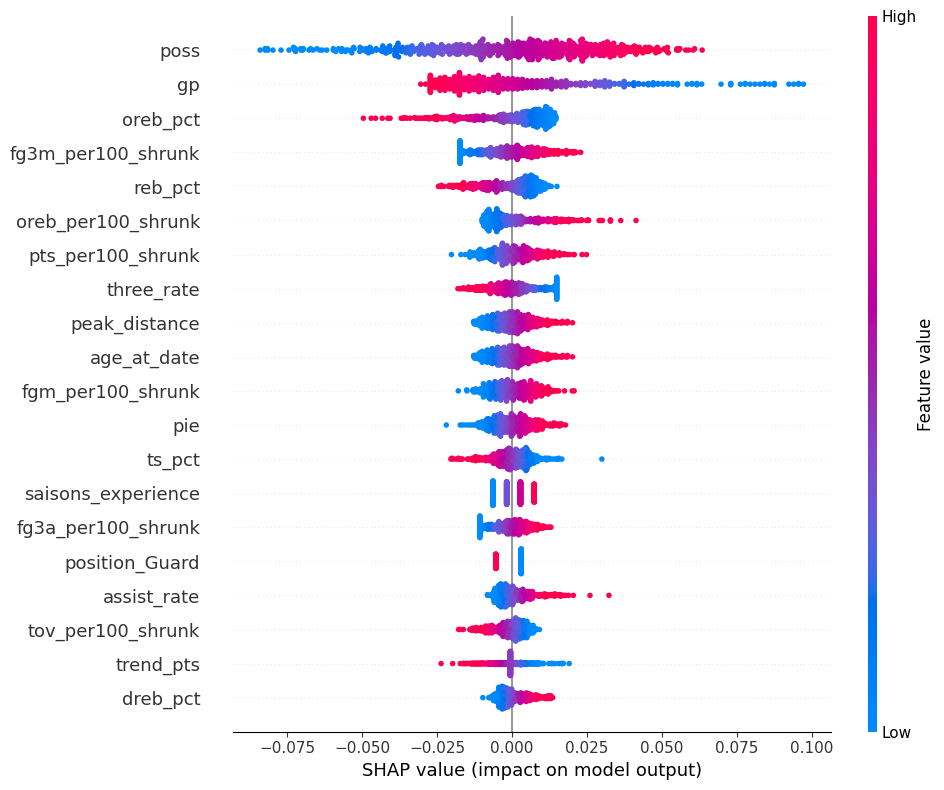

Image sauvegardée : shap_summary.png


In [25]:
import shap
import matplotlib.pyplot as plt
import numpy as np

X_transformed = pipeline_full.named_steps["preprocessor"].transform(X_full)

explainer = shap.LinearExplainer(
    pipeline_full.named_steps["model"],
    X_transformed
)
shap_values = explainer.shap_values(X_transformed)

# Output image
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=False,
    plot_size=None
)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Image sauvegardée : shap_summary.png")

Features V2 (sans PIE) : 32
Catégorielles          : ['position', 'valuation_tier']

MAE sans PIE (V2) : 0.0303 → 4,264,161$
MAE full (avec PIE) : 0.0306 → 4,298,721$
MAE 7 features PIE  : 0.0363 → 5,103,344$
Gain vs 7 features  : 16.4%


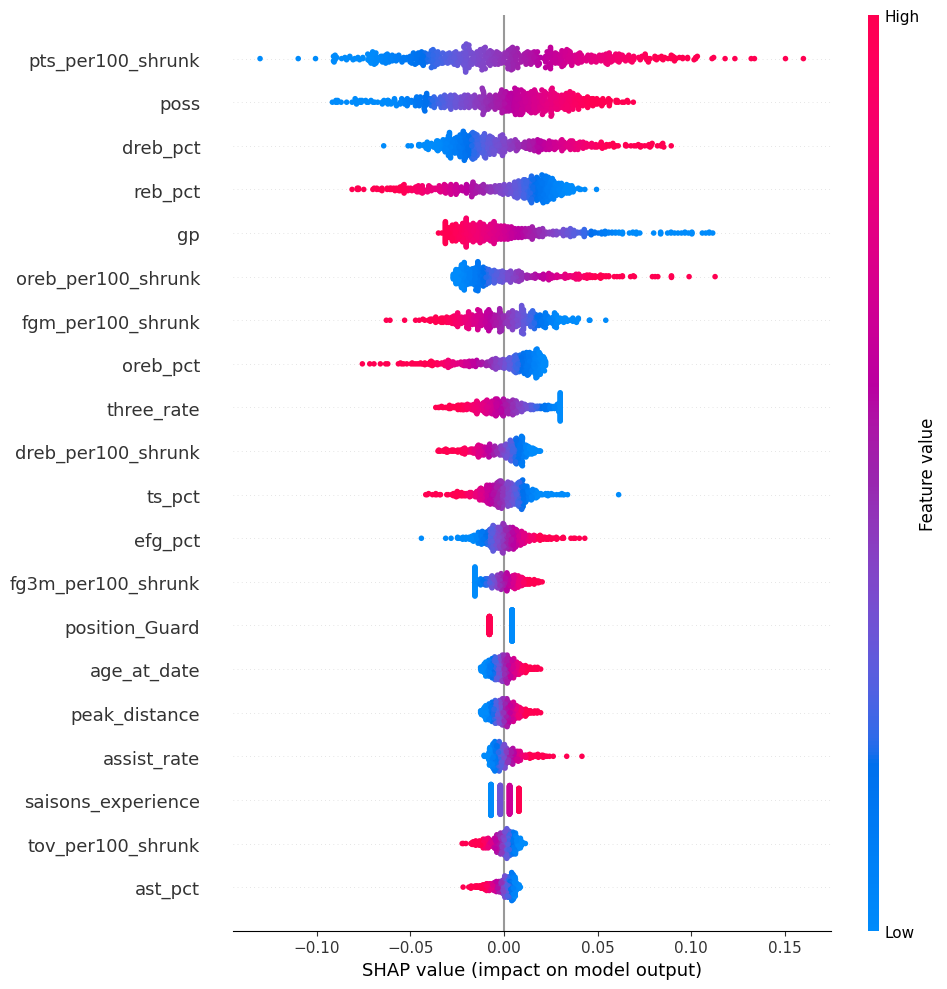

Image sauvegardée : shap_summary_v2.png


In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
import shap
import matplotlib.pyplot as plt

# ── Features par dimension ────────────────────────────────
SCORING     = ["pts_per100_shrunk", "fg3m_per100_shrunk", "fgm_per100_shrunk",
               "ts_pct", "efg_pct", "three_rate", "usg_pct"]
REBOUNDING  = ["reb_per100_shrunk", "oreb_per100_shrunk", "dreb_per100_shrunk",
               "oreb_pct", "dreb_pct", "reb_pct"]
PLAYMAKING  = ["ast_per100_shrunk", "ast_pct", "assist_rate",
               "tov_per100_shrunk", "turnover_rate"]
DEFENSE     = ["stl_per100_shrunk", "blk_per100_shrunk", "def_rating",
               "blka_per100_shrunk"]
DISPO       = ["poss", "gp"]
PROFIL      = ["age_at_date", "peak_distance", "saisons_experience",
               "height_inches", "weight", "bmi"]
TENDANCE    = ["trend_pts", "trend_pie"]
CAT_FEATURES = ["position", "valuation_tier"]

# Sans PIE — composantes séparées
NUM_FEATURES_V2 = (
    SCORING + REBOUNDING + PLAYMAKING +
    DEFENSE + DISPO + PROFIL + TENDANCE
)

print(f"Features V2 (sans PIE) : {len(NUM_FEATURES_V2)}")
print(f"Catégorielles          : {CAT_FEATURES}")

# ── Pipeline ──────────────────────────────────────────────
X_v2 = pairs[NUM_FEATURES_V2 + CAT_FEATURES]
y    = pairs["cap_hit_pct"].values

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
cat_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_FEATURES_V2),
    ("cat", cat_pipe, CAT_FEATURES),
])
pipeline_v2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=[0.1, 1, 10, 50, 100, 200])),
])

pipeline_v2.fit(X_v2, y)
y_pred_v2 = pipeline_v2.predict(X_v2)
mae_v2 = mean_absolute_error(y, y_pred_v2)

print(f"\nMAE sans PIE (V2) : {mae_v2:.4f} → {mae_v2*140_588_000:,.0f}$")
print(f"MAE full (avec PIE) : 0.0306 → 4,298,721$")
print(f"MAE 7 features PIE  : 0.0363 → 5,103,344$")
print(f"Gain vs 7 features  : {(0.0363 - mae_v2)/0.0363:.1%}")

# ── SHAP ──────────────────────────────────────────────────
feature_names_v2 = (
    NUM_FEATURES_V2 +
    pipeline_v2.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CAT_FEATURES).tolist()
)

X_transformed_v2 = pipeline_v2.named_steps["preprocessor"].transform(X_v2)
explainer_v2 = shap.LinearExplainer(pipeline_v2.named_steps["model"], X_transformed_v2)
shap_values_v2 = explainer_v2.shap_values(X_transformed_v2)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(
    shap_values_v2,
    X_transformed_v2,
    feature_names=feature_names_v2,
    show=False,
    plot_size=None
)
plt.tight_layout()
plt.savefig("shap_summary_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Image sauvegardée : shap_summary_v2.png")

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.optimize import minimize
from scipy.stats import norm

# ── Features ──────────────────────────────────────────────
SCORING     = ["pts_per100_shrunk", "fg3m_per100_shrunk", "fgm_per100_shrunk",
               "ts_pct", "efg_pct", "three_rate", "usg_pct"]
REBOUNDING  = ["reb_per100_shrunk", "oreb_per100_shrunk", "dreb_per100_shrunk",
               "oreb_pct", "dreb_pct", "reb_pct"]
PLAYMAKING  = ["ast_per100_shrunk", "ast_pct", "assist_rate",
               "tov_per100_shrunk", "turnover_rate"]
DEFENSE     = ["stl_per100_shrunk", "blk_per100_shrunk", "def_rating",
               "blka_per100_shrunk"]
DISPO       = ["poss", "gp"]
PROFIL      = ["age_at_date", "peak_distance", "saisons_experience",
               "height_inches", "weight", "bmi"]
TENDANCE    = ["trend_pts", "trend_pie"]
CAT_FEATURES = ["position", "valuation_tier"]

NUM_FEATURES_V2 = (
    SCORING + REBOUNDING + PLAYMAKING +
    DEFENSE + DISPO + PROFIL + TENDANCE
)

# ── Préparer X et y ───────────────────────────────────────
X_raw = pairs[NUM_FEATURES_V2].copy()
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_raw)
X_df  = pd.DataFrame(X_imp, columns=NUM_FEATURES_V2)

# Encoder les catégorielles
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = enc.fit_transform(pairs[CAT_FEATURES].fillna("unknown"))
cat_names = enc.get_feature_names_out(CAT_FEATURES).tolist()
X_cat_df = pd.DataFrame(X_cat, columns=cat_names)

# DataFrame complet
X_full_df = pd.concat([X_df, X_cat_df], axis=1).reset_index(drop=True)
X_const   = sm.add_constant(X_full_df.values)
y = pairs["cap_hit_pct"].values
feature_names_all = NUM_FEATURES_V2 + cat_names

# ══════════════════════════════════════════════════════════
# 1. OLS
# ══════════════════════════════════════════════════════════
ols_model = sm.OLS(y, X_const).fit()
y_pred_ols = ols_model.predict(X_const)
mae_ols = mean_absolute_error(y, y_pred_ols)

print("── OLS ──")
print(f"R²        : {ols_model.rsquared:.3f}")
print(f"R² ajusté : {ols_model.rsquared_adj:.3f}")
print(f"MAE       : {mae_ols:.4f} → {mae_ols*140_588_000:,.0f}$")
print(f"\nCoefficients significatifs (p<0.05) :")
params_df = pd.DataFrame({
    "feature": ["const"] + feature_names_all,
    "coef"   : ols_model.params,
    "pvalue" : ols_model.pvalues
})
sig = params_df[params_df["pvalue"] < 0.05].sort_values("pvalue")
print(sig.to_string(index=False))

# ══════════════════════════════════════════════════════════
# 2. GAMMA GLM
# ══════════════════════════════════════════════════════════
gamma_model = sm.GLM(
    y, X_const,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()
y_pred_gamma = gamma_model.predict(X_const)
mae_gamma = mean_absolute_error(y, y_pred_gamma)

print("\n── GAMMA GLM ──")
print(f"MAE : {mae_gamma:.4f} → {mae_gamma*140_588_000:,.0f}$")
print(f"AIC : {gamma_model.aic:.1f}")

# ══════════════════════════════════════════════════════════
# 3. BETA REGRESSION
# ══════════════════════════════════════════════════════════
y_beta = y.clip(1e-6, 1 - 1e-6)
X_beta_df = X_full_df.copy()
X_beta_df["cap_hit_pct"] = y_beta
formula_b = "cap_hit_pct ~ " + " + ".join(
    [f"Q('{c}')" if " " in c or "-" in c else c for c in feature_names_all]
)
beta_model = smf.glm(
    formula=formula_b,
    data=X_beta_df,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()
y_pred_beta = beta_model.predict(X_beta_df)
mae_beta = mean_absolute_error(y_beta, y_pred_beta)

print("\n── BETA REGRESSION ──")
print(f"MAE : {mae_beta:.4f} → {mae_beta*140_588_000:,.0f}$")
print(f"AIC : {beta_model.aic:.1f}")

# ══════════════════════════════════════════════════════════
# 4. TOBIT
# ══════════════════════════════════════════════════════════
LOW, HIGH = 0.05, 0.25

def tobit_loglik(params):
    beta  = params[:-1]
    sigma = np.exp(params[-1])
    xb    = X_const @ beta
    ll    = 0
    mask      = (y > LOW) & (y < HIGH)
    mask_low  = y <= LOW
    mask_high = y >= HIGH
    if mask.sum() > 0:
        ll += np.sum(norm.logpdf(y[mask], loc=xb[mask], scale=sigma))
    if mask_low.sum() > 0:
        ll += np.sum(norm.logcdf(LOW, loc=xb[mask_low], scale=sigma))
    if mask_high.sum() > 0:
        ll += np.sum(norm.logsf(HIGH, loc=xb[mask_high], scale=sigma))
    return -ll

lr_init    = LinearRegression().fit(X_const, y)
beta_init  = np.append(lr_init.coef_, np.log(np.std(y)))
beta_init[0] = lr_init.intercept_
result     = minimize(tobit_loglik, beta_init, method="L-BFGS-B",
                      options={"maxiter": 1000})
beta_tobit    = result.x[:-1]
y_pred_tobit  = np.clip(X_const @ beta_tobit, LOW, HIGH)
mae_tobit     = mean_absolute_error(y, y_pred_tobit)

print("\n── TOBIT ──")
print(f"MAE         : {mae_tobit:.4f} → {mae_tobit*140_588_000:,.0f}$")
print(f"Convergence : {result.success}")

# ══════════════════════════════════════════════════════════
# 5. QUANTILE REGRESSION (P25 / P50 / P75)
# ══════════════════════════════════════════════════════════
X_quant_df = X_full_df.copy()
X_quant_df["cap_hit_pct"] = y
formula_q  = "cap_hit_pct ~ " + " + ".join(NUM_FEATURES_V2)

maes_q   = {}
models_q = {}
for label, q in {"Q25": 0.25, "Q50": 0.50, "Q75": 0.75}.items():
    m = smf.quantreg(formula_q, data=X_quant_df).fit(q=q, max_iter=2000)
    pred = m.predict(X_quant_df)
    maes_q[label]  = mean_absolute_error(y, pred)
    models_q[label] = m

print("\n── QUANTILE REGRESSION ──")
for label, mae in maes_q.items():
    print(f"  {label} : MAE={mae:.4f} → {mae*140_588_000:,.0f}$")

# ══════════════════════════════════════════════════════════
# COMPARAISON FINALE
# ══════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("COMPARAISON COMPLÈTE — SANS PIE, TOUS PARAMÈTRES")
print(f"{'='*60}")
resultats = {
    "Baseline moyenne"      : 0.0448,
    "Ridge V2 (ref)"        : 0.0303,
    "OLS"                   : mae_ols,
    "Gamma GLM"             : mae_gamma,
    "Beta Regression"       : mae_beta,
    "Tobit"                 : mae_tobit,
    "Quantile Q50"          : maes_q["Q50"],
}
for nom, mae in sorted(resultats.items(), key=lambda x: x[1]):
    gain = (0.0448 - mae) / 0.0448
    print(f"{nom:<25} MAE={mae:.4f} → {mae*140_588_000:,.0f}$  ({gain:+.1%} vs baseline)")

── OLS ──
R²        : 0.491
R² ajusté : 0.456
MAE       : 0.0301 → 4,229,205$

Coefficients significatifs (p<0.05) :
                         feature      coef       pvalue
                            poss  0.000027 1.420921e-20
                              gp -0.001858 7.027167e-17
               pts_per100_shrunk  0.011187 1.118300e-03
              saisons_experience  0.005082 2.081734e-03
valuation_tier_replacement_level -0.041009 2.249121e-03
         valuation_tier_reliable  0.025399 3.045972e-03
          position_Forward-Guard -0.018218 1.023191e-02
         position_Forward-Center  0.014732 1.856081e-02
                      three_rate -0.077013 1.899343e-02
                      def_rating -0.001228 2.268925e-02
                       trend_pts -0.001964 2.850169e-02
                        dreb_pct  1.547085 3.282378e-02
               fgm_per100_shrunk -0.014502 3.612865e-02
       valuation_tier_low_sample  0.015936 3.976518e-02
                  position_Guard -0.012844 

C:\Users\user\AppData\Local\Temp\ipykernel_29568\3169419814.py:55: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_model = sm.OLS(y, X_const).fit()
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)



── BETA REGRESSION ──
MAE : 0.0291 → 4,091,788$
AIC : 386.8

── TOBIT ──
MAE         : 0.0296 → 4,158,408$
Convergence : True


C:\Users\user\AppData\Local\Temp\ipykernel_29568\3169419814.py:151: IterationLimitWarning: Maximum number of iterations (2000) reached.
  m = smf.quantreg(formula_q, data=X_quant_df).fit(q=q, max_iter=2000)



── QUANTILE REGRESSION ──
  Q25 : MAE=0.0370 → 5,203,594$
  Q50 : MAE=0.0302 → 4,249,033$
  Q75 : MAE=0.0377 → 5,295,288$

COMPARAISON COMPLÈTE — SANS PIE, TOUS PARAMÈTRES
Beta Regression           MAE=0.0291 → 4,091,788$  (+35.0% vs baseline)
Gamma GLM                 MAE=0.0294 → 4,136,076$  (+34.3% vs baseline)
Tobit                     MAE=0.0296 → 4,158,408$  (+34.0% vs baseline)
OLS                       MAE=0.0301 → 4,229,205$  (+32.9% vs baseline)
Quantile Q50              MAE=0.0302 → 4,249,033$  (+32.5% vs baseline)
Ridge V2 (ref)            MAE=0.0303 → 4,259,816$  (+32.4% vs baseline)
Baseline moyenne          MAE=0.0448 → 6,298,342$  (+0.0% vs baseline)


In [28]:
EXCLUDE = [
    "cap_hit_pct", "cap_hit",
    "player_id", "saison", "saison_key", "team_id", "feature_version",
    "salary_cap", "sample_weight",
    "position", "valuation_tier",
    # Colonnes calculées dans le notebook
    "log_cap_hit_pct", "log_pie", "valeur_base_pct", "valeur_estimee_pct",
    "valeur_estimee_dollars", "valeur_base_seule", "pie_quartile",
    "fg3_rank", "def_rank", "m_dispo", "m_tendance", "m_age", "m_rarete",
    # PIE — on l'exclut
    "pie",
]

NUM_FEATURES_45 = [
    c for c in pairs.columns
    if c not in EXCLUDE
    and c not in ["position", "valuation_tier"]
    and pairs[c].dtype in ["float64", "int64", "float32", "int32"]
]

print(f"Features sans PIE : {len(NUM_FEATURES_45)}")
print(NUM_FEATURES_45)

Features sans PIE : 44
['poss', 'gp', 'height_inches', 'weight', 'bmi', 'age_at_date', 'peak_distance', 'saisons_experience', 'pts_per100_shrunk', 'reb_per100_shrunk', 'ast_per100_shrunk', 'stl_per100_shrunk', 'blk_per100_shrunk', 'tov_per100_shrunk', 'fgm_per100_shrunk', 'fga_per100_shrunk', 'fg3m_per100_shrunk', 'fg3a_per100_shrunk', 'ftm_per100_shrunk', 'fta_per100_shrunk', 'oreb_per100_shrunk', 'dreb_per100_shrunk', 'plus_minus_per100_shrunk', 'blka_per100_shrunk', 'pf_per100_shrunk', 'fg_pct', 'fg3_pct', 'ft_pct', 'efg_pct', 'ts_pct', 'off_rating', 'def_rating', 'net_rating', 'usg_pct', 'ast_pct', 'oreb_pct', 'dreb_pct', 'reb_pct', 'three_rate', 'free_throw_rate', 'turnover_rate', 'assist_rate', 'trend_pts', 'trend_pie']


In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.optimize import minimize
from scipy.stats import norm

NUM_FEATURES_44 = ['poss', 'gp', 'height_inches', 'weight', 'bmi', 'age_at_date', 
'peak_distance', 'saisons_experience', 'pts_per100_shrunk', 'reb_per100_shrunk', 
'ast_per100_shrunk', 'stl_per100_shrunk', 'blk_per100_shrunk', 'tov_per100_shrunk', 
'fgm_per100_shrunk', 'fga_per100_shrunk', 'fg3m_per100_shrunk', 'fg3a_per100_shrunk', 
'ftm_per100_shrunk', 'fta_per100_shrunk', 'oreb_per100_shrunk', 'dreb_per100_shrunk', 
'plus_minus_per100_shrunk', 'blka_per100_shrunk', 'pf_per100_shrunk', 'fg_pct', 
'fg3_pct', 'ft_pct', 'efg_pct', 'ts_pct', 'off_rating', 'def_rating', 'net_rating', 
'usg_pct', 'ast_pct', 'oreb_pct', 'dreb_pct', 'reb_pct', 'three_rate', 
'free_throw_rate', 'turnover_rate', 'assist_rate', 'trend_pts', 'trend_pie']

CAT_FEATURES = ["position", "valuation_tier"]

# ── Préparer X et y ───────────────────────────────────────
X_raw = pairs[NUM_FEATURES_44].copy()
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_raw)
X_df  = pd.DataFrame(X_imp, columns=NUM_FEATURES_44)

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = enc.fit_transform(pairs[CAT_FEATURES].fillna("unknown"))
cat_names = enc.get_feature_names_out(CAT_FEATURES).tolist()
X_cat_df = pd.DataFrame(X_cat, columns=cat_names)

X_full_df = pd.concat([X_df, X_cat_df], axis=1).reset_index(drop=True)
X_const   = sm.add_constant(X_full_df.values)
y = pairs["cap_hit_pct"].values
feature_names_all = NUM_FEATURES_44 + cat_names

# ══════════════════════════════════════════════════════════
# 1. OLS
# ══════════════════════════════════════════════════════════
ols_model   = sm.OLS(y, X_const).fit()
mae_ols     = mean_absolute_error(y, ols_model.predict(X_const))

print("── OLS ──")
print(f"R²        : {ols_model.rsquared:.3f}")
print(f"R² ajusté : {ols_model.rsquared_adj:.3f}")
print(f"MAE       : {mae_ols:.4f} → {mae_ols*140_588_000:,.0f}$")

# ══════════════════════════════════════════════════════════
# 2. GAMMA GLM
# ══════════════════════════════════════════════════════════
gamma_model = sm.GLM(
    y, X_const,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()
mae_gamma = mean_absolute_error(y, gamma_model.predict(X_const))

print("\n── GAMMA GLM ──")
print(f"MAE : {mae_gamma:.4f} → {mae_gamma*140_588_000:,.0f}$")

# ══════════════════════════════════════════════════════════
# 3. BETA REGRESSION
# ══════════════════════════════════════════════════════════
y_beta    = y.clip(1e-6, 1 - 1e-6)
X_beta_df = X_full_df.copy()
X_beta_df["cap_hit_pct"] = y_beta
formula_b = "cap_hit_pct ~ " + " + ".join(
    [f"Q('{c}')" if any(s in c for s in [" ", "-", "/"]) else c 
     for c in feature_names_all]
)
beta_model  = smf.glm(
    formula=formula_b, data=X_beta_df,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()
mae_beta = mean_absolute_error(y_beta, beta_model.predict(X_beta_df))

print("\n── BETA REGRESSION ──")
print(f"MAE : {mae_beta:.4f} → {mae_beta*140_588_000:,.0f}$")

# ══════════════════════════════════════════════════════════
# 4. TOBIT
# ══════════════════════════════════════════════════════════
LOW, HIGH = 0.05, 0.25

def tobit_loglik(params):
    beta  = params[:-1]
    sigma = np.exp(params[-1])
    xb    = X_const @ beta
    ll    = 0
    mask      = (y > LOW) & (y < HIGH)
    mask_low  = y <= LOW
    mask_high = y >= HIGH
    if mask.sum() > 0:
        ll += np.sum(norm.logpdf(y[mask], loc=xb[mask], scale=sigma))
    if mask_low.sum() > 0:
        ll += np.sum(norm.logcdf(LOW, loc=xb[mask_low], scale=sigma))
    if mask_high.sum() > 0:
        ll += np.sum(norm.logsf(HIGH, loc=xb[mask_high], scale=sigma))
    return -ll

lr_init      = LinearRegression().fit(X_const, y)
beta_init    = np.append(lr_init.coef_, np.log(np.std(y)))
beta_init[0] = lr_init.intercept_
result       = minimize(tobit_loglik, beta_init, method="L-BFGS-B",
                        options={"maxiter": 1000})
y_pred_tobit = np.clip(X_const @ result.x[:-1], LOW, HIGH)
mae_tobit    = mean_absolute_error(y, y_pred_tobit)

print("\n── TOBIT ──")
print(f"MAE         : {mae_tobit:.4f} → {mae_tobit*140_588_000:,.0f}$")
print(f"Convergence : {result.success}")

# ══════════════════════════════════════════════════════════
# 5. RIDGE
# ══════════════════════════════════════════════════════════
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler", StandardScaler())])
cat_pipe = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore",
                                                sparse_output=False))])
preprocessor = ColumnTransformer([("num", num_pipe, NUM_FEATURES_44),
                                   ("cat", cat_pipe, CAT_FEATURES)])
pipeline_ridge = Pipeline([("preprocessor", preprocessor),
                            ("model", RidgeCV(alphas=[0.1, 1, 10, 50, 100, 200]))])
pipeline_ridge.fit(pairs[NUM_FEATURES_44 + CAT_FEATURES], y)
mae_ridge = mean_absolute_error(y, pipeline_ridge.predict(
    pairs[NUM_FEATURES_44 + CAT_FEATURES]))

print("\n── RIDGE ──")
print(f"MAE : {mae_ridge:.4f} → {mae_ridge*140_588_000:,.0f}$")

# ══════════════════════════════════════════════════════════
# COMPARAISON FINALE
# ══════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("COMPARAISON — 44 FEATURES SANS PIE + POSITION")
print(f"{'='*65}")
resultats = {
    "Baseline"              : 0.0448,
    "Ridge 32f (ref)"       : 0.0303,
    "Beta 32f (ref)"        : 0.0291,
    "Ridge 44f"             : mae_ridge,
    "OLS 44f"               : mae_ols,
    "Gamma GLM 44f"         : mae_gamma,
    "Beta Regression 44f"   : mae_beta,
    "Tobit 44f"             : mae_tobit,
}
for nom, mae in sorted(resultats.items(), key=lambda x: x[1]):
    gain = (0.0448 - mae) / 0.0448
    print(f"{nom:<25} MAE={mae:.4f} → {mae*140_588_000:,.0f}$  ({gain:+.1%} vs baseline)")

── OLS ──
R²        : 0.502
R² ajusté : 0.455
MAE       : 0.0298 → 4,183,364$

── GAMMA GLM ──
MAE : 0.0289 → 4,060,338$


C:\Users\user\AppData\Local\Temp\ipykernel_29568\6758854.py:45: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_model   = sm.OLS(y, X_const).fit()
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)



── BETA REGRESSION ──
MAE : 0.0286 → 4,014,080$

── TOBIT ──
MAE         : 0.0292 → 4,107,148$
Convergence : True

── RIDGE ──
MAE : 0.0306 → 4,302,973$

COMPARAISON — 44 FEATURES SANS PIE + POSITION
Beta Regression 44f       MAE=0.0286 → 4,014,080$  (+36.3% vs baseline)
Gamma GLM 44f             MAE=0.0289 → 4,060,338$  (+35.5% vs baseline)
Beta 32f (ref)            MAE=0.0291 → 4,091,111$  (+35.0% vs baseline)
Tobit 44f                 MAE=0.0292 → 4,107,148$  (+34.8% vs baseline)
OLS 44f                   MAE=0.0298 → 4,183,364$  (+33.6% vs baseline)
Ridge 32f (ref)           MAE=0.0303 → 4,259,816$  (+32.4% vs baseline)
Ridge 44f                 MAE=0.0306 → 4,302,973$  (+31.7% vs baseline)
Baseline                  MAE=0.0448 → 6,298,342$  (+0.0% vs baseline)


In [30]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

CAT_FEATURES = ["position", "valuation_tier"]

# ══════════════════════════════════════════════════════════
# 1. SCORE DE RARETÉ PAR POSTE
# ══════════════════════════════════════════════════════════
pairs_fe = pairs.copy()

RARETE_FEATURES = [
    "pts_per100_shrunk", "fg3m_per100_shrunk", "ast_per100_shrunk",
    "stl_per100_shrunk", "blk_per100_shrunk", "reb_per100_shrunk"
]

for feat in RARETE_FEATURES:
    col_name = f"rarete_{feat}"
    pairs_fe[col_name] = pairs_fe.groupby("position")[feat].rank(pct=True)

RARETE_COLS = [f"rarete_{f}" for f in RARETE_FEATURES]
print(f"✅ Rareté par poste : {len(RARETE_COLS)} features")

# ══════════════════════════════════════════════════════════
# 2. INTERACTIONS SKILLS × POSITION
# ══════════════════════════════════════════════════════════
pairs_fe["is_guard"]   = (pairs_fe["position"] == "Guard").astype(int)
pairs_fe["is_center"]  = (pairs_fe["position"] == "Center").astype(int)
pairs_fe["is_forward"] = (pairs_fe["position"] == "Forward").astype(int)

# Skills premium par poste
pairs_fe["scoring_guard"]    = pairs_fe["pts_per100_shrunk"] * pairs_fe["is_guard"]
pairs_fe["shooting_guard"]   = pairs_fe["fg3m_per100_shrunk"] * pairs_fe["is_guard"]
pairs_fe["playmaking_guard"] = pairs_fe["ast_per100_shrunk"] * pairs_fe["is_guard"]
pairs_fe["rim_center"]       = pairs_fe["blk_per100_shrunk"] * pairs_fe["is_center"]
pairs_fe["reb_center"]       = pairs_fe["reb_per100_shrunk"] * pairs_fe["is_center"]
pairs_fe["versatile_fwd"]    = pairs_fe["fg3m_per100_shrunk"] * pairs_fe["is_forward"]

INTERACTION_COLS = [
    "scoring_guard", "shooting_guard", "playmaking_guard",
    "rim_center", "reb_center", "versatile_fwd"
]
print(f"✅ Interactions skills×poste : {len(INTERACTION_COLS)} features")

# ══════════════════════════════════════════════════════════
# 3. RATIO EFFICACITÉ / VOLUME
# ══════════════════════════════════════════════════════════
pairs_fe["efficacite_scoring"] = (
    pairs_fe["pts_per100_shrunk"] / pairs_fe["usg_pct"].clip(0.1)
)
pairs_fe["efficacite_shoot3"]  = (
    pairs_fe["fg3m_per100_shrunk"] / pairs_fe["fg3a_per100_shrunk"].clip(0.1)
)
pairs_fe["efficacite_passe"]   = (
    pairs_fe["ast_per100_shrunk"] / pairs_fe["tov_per100_shrunk"].clip(0.1)
)

RATIO_COLS = ["efficacite_scoring", "efficacite_shoot3", "efficacite_passe"]
print(f"✅ Ratios efficacité/volume : {len(RATIO_COLS)} features")

# ══════════════════════════════════════════════════════════
# 4. INDEX DE POLYVALENCE
# ══════════════════════════════════════════════════════════
POLY_FEATURES = [
    "pts_per100_shrunk", "reb_per100_shrunk", "ast_per100_shrunk",
    "stl_per100_shrunk", "blk_per100_shrunk"
]
pairs_fe["polyvalence"] = pairs_fe[POLY_FEATURES].std(axis=1)
pairs_fe["niveau_global"] = pairs_fe[POLY_FEATURES].mean(axis=1)

POLY_COLS = ["polyvalence", "niveau_global"]
print(f"✅ Index polyvalence : {len(POLY_COLS)} features")

# ══════════════════════════════════════════════════════════
# 5. PCA — RÉDUIRE LA COLINÉARITÉ REBOND
# ══════════════════════════════════════════════════════════
REB_FEATURES = [
    "reb_per100_shrunk", "oreb_per100_shrunk", "dreb_per100_shrunk",
    "oreb_pct", "dreb_pct", "reb_pct"
]
imp_reb = SimpleImputer(strategy="median")
X_reb   = imp_reb.fit_transform(pairs_fe[REB_FEATURES])
pca_reb = PCA(n_components=2)
X_reb_pca = pca_reb.fit_transform(X_reb)
pairs_fe["pca_reb_1"] = X_reb_pca[:, 0]
pairs_fe["pca_reb_2"] = X_reb_pca[:, 1]

print(f"✅ PCA rebond : variance expliquée {pca_reb.explained_variance_ratio_.sum():.1%}")
PCA_COLS = ["pca_reb_1", "pca_reb_2"]

# ══════════════════════════════════════════════════════════
# DATASET FINAL
# ══════════════════════════════════════════════════════════
NUM_BASE = ['poss', 'gp', 'height_inches', 'weight', 'bmi', 'age_at_date',
'peak_distance', 'saisons_experience', 'pts_per100_shrunk', 'ast_per100_shrunk',
'stl_per100_shrunk', 'blk_per100_shrunk', 'tov_per100_shrunk', 'fgm_per100_shrunk',
'fga_per100_shrunk', 'fg3m_per100_shrunk', 'fg3a_per100_shrunk', 'ftm_per100_shrunk',
'fta_per100_shrunk', 'plus_minus_per100_shrunk', 'blka_per100_shrunk',
'pf_per100_shrunk', 'fg_pct', 'fg3_pct', 'ft_pct', 'efg_pct', 'ts_pct',
'off_rating', 'def_rating', 'net_rating', 'usg_pct', 'ast_pct',
'three_rate', 'free_throw_rate', 'turnover_rate', 'assist_rate',
'trend_pts', 'trend_pie']

# Remplacer les features rebond brutes par PCA
ALL_FEATURES = (
    NUM_BASE +
    RARETE_COLS +
    INTERACTION_COLS +
    RATIO_COLS +
    POLY_COLS +
    PCA_COLS
)

print(f"\nTotal features V3 : {len(ALL_FEATURES)}")

# ── Préparer X et y ───────────────────────────────────────
X_raw = pairs_fe[ALL_FEATURES].copy()
imp   = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_raw)
X_df  = pd.DataFrame(X_imp, columns=ALL_FEATURES)

enc      = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat    = enc.fit_transform(pairs_fe[CAT_FEATURES].fillna("unknown"))
cat_names = enc.get_feature_names_out(CAT_FEATURES).tolist()
X_cat_df  = pd.DataFrame(X_cat, columns=cat_names)

X_full_df = pd.concat([X_df, X_cat_df], axis=1).reset_index(drop=True)
y         = pairs_fe["cap_hit_pct"].values

# ── Beta Regression ───────────────────────────────────────
y_beta    = y.clip(1e-6, 1 - 1e-6)
X_beta_df = X_full_df.copy()
X_beta_df["cap_hit_pct"] = y_beta
formula_b = "cap_hit_pct ~ " + " + ".join(
    [f"Q('{c}')" if any(s in c for s in [" ", "-", "/"]) else c
     for c in ALL_FEATURES + cat_names]
)
beta_v3  = smf.glm(
    formula=formula_b, data=X_beta_df,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()
mae_beta_v3 = mean_absolute_error(y_beta, beta_v3.predict(X_beta_df))

# ── Comparaison ───────────────────────────────────────────
print(f"\n{'='*60}")
print("COMPARAISON — IMPACT DU FEATURE ENGINEERING")
print(f"{'='*60}")
resultats = {
    "Baseline"              : 0.0448,
    "Beta 44f (sans FE)"    : 0.0286,
    "Beta V3 (avec FE)"     : mae_beta_v3,
}
for nom, mae in sorted(resultats.items(), key=lambda x: x[1]):
    gain = (0.0448 - mae) / 0.0448
    print(f"{nom:<25} MAE={mae:.4f} → {mae*140_588_000:,.0f}$  ({gain:+.1%} vs baseline)")

✅ Rareté par poste : 6 features
✅ Interactions skills×poste : 6 features
✅ Ratios efficacité/volume : 3 features
✅ Index polyvalence : 2 features
✅ PCA rebond : variance expliquée 100.0%

Total features V3 : 57

COMPARAISON — IMPACT DU FEATURE ENGINEERING
Beta V3 (avec FE)         MAE=0.0281 → 3,952,885$  (+37.2% vs baseline)
Beta 44f (sans FE)        MAE=0.0286 → 4,020,817$  (+36.2% vs baseline)
Baseline                  MAE=0.0448 → 6,298,342$  (+0.0% vs baseline)


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


In [31]:
etapes = {
    "Beta 44f (base)"           : [],
    "+ Rareté par poste"        : RARETE_COLS,
    "+ Interactions pos×skill"  : RARETE_COLS + INTERACTION_COLS,
    "+ Ratios efficacité"       : RARETE_COLS + INTERACTION_COLS + RATIO_COLS,
    "+ Polyvalence"             : RARETE_COLS + INTERACTION_COLS + RATIO_COLS + POLY_COLS,
    "+ PCA rebond (V3 complet)" : RARETE_COLS + INTERACTION_COLS + RATIO_COLS + POLY_COLS + PCA_COLS,
}

print(f"{'='*65}")
print("CONTRIBUTION DE CHAQUE TRANSFORMATION")
print(f"{'='*65}")

for nom, extra_cols in etapes.items():
    features_test = NUM_BASE + extra_cols
    X_t   = pairs_fe[features_test].copy()
    X_imp_t = SimpleImputer(strategy="median").fit_transform(X_t)
    X_df_t  = pd.DataFrame(X_imp_t, columns=features_test)
    X_cat_t = pd.DataFrame(
        enc.transform(pairs_fe[CAT_FEATURES].fillna("unknown")),
        columns=cat_names
    )
    X_full_t = pd.concat([X_df_t, X_cat_t], axis=1).reset_index(drop=True)
    y_beta_t = y.clip(1e-6, 1 - 1e-6)
    X_full_t["cap_hit_pct"] = y_beta_t
    formula_t = "cap_hit_pct ~ " + " + ".join(
        [f"Q('{c}')" if any(s in c for s in [" ", "-", "/"]) else c
         for c in features_test + cat_names]
    )
    m = smf.glm(
        formula=formula_t, data=X_full_t,
        family=sm.families.Binomial(link=sm.families.links.Logit())
    ).fit(disp=0)
    mae = mean_absolute_error(y_beta_t, m.predict(X_full_t))
    gain = (0.0448 - mae) / 0.0448
    print(f"{nom:<30} MAE={mae:.4f} → {mae*140_588_000:,.0f}$  ({gain:+.1%})")

CONTRIBUTION DE CHAQUE TRANSFORMATION


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


Beta 44f (base)                MAE=0.0289 → 4,063,100$  (+35.5%)


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


+ Rareté par poste             MAE=0.0286 → 4,022,051$  (+36.1%)


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


+ Interactions pos×skill       MAE=0.0282 → 3,964,774$  (+37.1%)
+ Ratios efficacité            MAE=0.0282 → 3,970,928$  (+37.0%)


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


+ Polyvalence                  MAE=0.0281 → 3,947,921$  (+37.3%)
+ PCA rebond (V3 complet)      MAE=0.0281 → 3,952,885$  (+37.2%)


In [32]:
# Distribution des classes
SALARY_CAP_REF = 140_588_000

with engine.connect() as conn:
    df_all = pd.read_sql(text("""
        SELECT pf.*, p.position, c.cap_hit, c.saison as contrat_saison
        FROM player_features pf
        LEFT JOIN players p ON pf.player_id = p.player_id
        LEFT JOIN contracts c ON pf.player_id = c.player_id 
            AND pf.saison = c.saison
        WHERE pf.feature_version = :v
        AND c.cap_hit IS NOT NULL
    """), conn, params={"v": FEATURE_VERSION})

SALARY_CAP = {
    "2021-22": 112_414_000,
    "2022-23": 123_655_000,
    "2023-24": 136_021_000,
    "2024-25": 140_588_000,
}

df_all["saison_key"] = df_all["saison"].apply(
    lambda s: f"{int(s[:4])-1}-{s[:4][2:]}"
)
df_all["salary_cap"]   = df_all["saison_key"].map(SALARY_CAP)
df_all["cap_hit_pct"]  = df_all["cap_hit"] / df_all["salary_cap"]

# Segmentation
df_all["segment"] = pd.cut(
    df_all["cap_hit_pct"],
    bins=[0, 0.05, 0.15, 0.25, 1.0],
    labels=["rookie_minimum", "low_middle", "high_middle", "max"]
)

print("Distribution par segment :")
print(df_all["segment"].value_counts().sort_index())
print(f"\nTotal : {len(df_all)} paires")
print(f"\nStats cap_hit_pct par segment :")
print(df_all.groupby("segment")["cap_hit_pct"].describe().round(3))

Distribution par segment :
segment
rookie_minimum    969
low_middle        478
high_middle       160
max               167
Name: count, dtype: int64

Total : 2209 paires

Stats cap_hit_pct par segment :
                count   mean    std    min    25%    50%    75%    max
segment                                                               
rookie_minimum  969.0  0.020  0.012  0.000  0.014  0.017  0.028  0.050
low_middle      478.0  0.089  0.027  0.050  0.065  0.084  0.105  0.150
high_middle     160.0  0.192  0.029  0.150  0.167  0.188  0.218  0.250
max             167.0  0.318  0.046  0.252  0.275  0.312  0.361  0.428


C:\Users\user\AppData\Local\Temp\ipykernel_29568\457776207.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_all.groupby("segment")["cap_hit_pct"].describe().round(3))


In [33]:
# PRIORITÉ 1 — Cross-validation sur Beta V3
# C'est le seul test qui dira si le modèle généralise vraiment

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import statsmodels.formula.api as smf
import statsmodels.api as sm

kf = KFold(n_splits=5, shuffle=False)
maes_cv = []

for train_idx, test_idx in kf.split(X_full_df):
    X_tr = X_full_df.iloc[train_idx].copy()
    X_te = X_full_df.iloc[test_idx].copy()
    y_tr = y[train_idx].clip(1e-6, 1-1e-6)
    y_te = y[test_idx]
    
    X_tr["cap_hit_pct"] = y_tr
    formula_cv = "cap_hit_pct ~ " + " + ".join(
        [f"Q('{c}')" if any(s in c for s in [" ", "-", "/"]) else c 
         for c in ALL_FEATURES + cat_names]
    )
    m = smf.glm(
        formula=formula_cv, data=X_tr,
        family=sm.families.Binomial(link=sm.families.links.Logit())
    ).fit(disp=0)
    
    y_pred = m.predict(X_te)
    maes_cv.append(mean_absolute_error(y_te, y_pred))

print(f"CV MAE Beta V3 : {np.mean(maes_cv):.4f} → {np.mean(maes_cv)*140_588_000:,.0f}$")
print(f"Std             : {np.std(maes_cv):.4f}")
print(f"MAE in-sample   : 0.0281 → 3,952,885$")

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


CV MAE Beta V3 : 0.0380 → 5,339,798$
Std             : 0.0060
MAE in-sample   : 0.0281 → 3,952,885$


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
